# Incident reports — generate a run & explore

This notebook can **trigger a full ingestion run** and then **explore** its
output interactively.

Golden rule: it **reuses** the logic from `src/` (runner, loader, config) and
**never duplicates** it. The exact same orchestration powers
`scripts/run_ingestion.py`. Once an analysis becomes stable and useful, promote
it into `src/` and expose it through the CLI.

## 0. Setup

Make the `src` package importable and enable inline plots. `config` paths are
absolute (derived from `src/config.py`), so they work regardless of the kernel's
working directory.

In [13]:
import sys
from pathlib import Path

# Resolve the project root whether the kernel starts in notebooks/ or the repo root.
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

from src import config

print("Project root:", PROJECT_ROOT)
print("Artifacts dir:", config.ARTIFACTS_DIR)

Project root: z:\formation_aelion\project\vs_code
Artifacts dir: Z:\formation_aelion\project\vs_code\artifacts\ingestions\incidents


## 1. Generate a fresh run (or pick the latest)

`run_from_env` reads `ANONYMIZATION_SALT` from `.env`, runs the whole pipeline
(load → anonymise → enrich) and writes all artifacts into a new timestamped
folder, exactly like the CLI.

- Set `GENERATE_NEW_RUN = True` to produce a brand-new run.
- Set it to `False` to only explore the most recent existing run.

> Each generation creates a **new** timestamped folder; it never overwrites a
> previous run. Anonymisation is deterministic, so the data is identical across
> runs (same salt).

In [14]:
from src.ingestion.runner import run_from_env

GENERATE_NEW_RUN = False  # set to False to only explore the latest existing run

if GENERATE_NEW_RUN:
    run_dir = run_from_env(config.DEFAULT_INPUT_CSV)
else:
    runs = sorted(
        p for p in config.ARTIFACTS_DIR.iterdir() if p.is_dir() and p.name.isdigit()
    )
    assert runs, "No run found. Set GENERATE_NEW_RUN = True to create one."
    run_dir = runs[-1]

RUN_ID = run_dir.name
print("Active run:", RUN_ID)
for f in sorted(run_dir.iterdir()):
    print("  -", f.name)

Active run: 202606161528
  - corr_incidents_signals.png
  - dist_incidents_day.png
  - dist_incidents_shift.png
  - dist_incidents_week.png
  - hist_signals_machine.png
  - incidents_anonymized.csv
  - run_report.md


## 2. Load the anonymised dataset

No salt is required here: the data produced by the run is already anonymised.

In [15]:
df = pd.read_csv(run_dir / "incidents_anonymized.csv", parse_dates=[config.DATE_COLUMN])
df.head()

,incident_id,date,time,operator_name,machine_id,severity,operator_badge,comment,shift,type_surchauffe,...,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite,datetime,comment_pii_flag,n_active_signals,confidence_index
0,INC-000001,2025-06-01,05:00,0f91661e3337f8f5,MACH-06,1,OP_F9965E,chauffe anormale,nuit,1,...,0,0,0,0,0,0,2025-06-01 05:00:00,True,1,0.1111
1,INC-000002,2025-06-01,21:00,7350eb0988b06c76,MACH-15,1,OP_24A324,micro-fuite / baisse pression,apres-midi,0,...,0,0,0,0,0,0,2025-06-01 21:00:00,True,1,0.1111
2,INC-000003,2025-06-01,22:00,0f91661e3337f8f5,MACH-12,2,OP_F9965E,bruit mécanique anormal,nuit,0,...,1,0,0,0,0,0,2025-06-01 22:00:00,True,1,0.1111
3,INC-000004,2025-06-04,05:00,0f91661e3337f8f5,MACH-10,1,OP_F9965E,alarme capteur,nuit,0,...,0,0,0,1,0,0,2025-06-04 05:00:00,True,1,0.1111
4,INC-000005,2025-06-04,22:00,a9a23ddd3ed5035f,MACH-01,2,OP_BE98CC,NaN,nuit,1,...,0,0,0,0,0,0,2025-06-04 22:00:00,False,1,0.1111


## 3. Dataset overview

Shape, dtypes and missing values at a glance.

In [16]:
print("Shape:", df.shape)
df.info()

Shape: (900, 22)
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   incident_id             900 non-null    str           
 1   date                    900 non-null    datetime64[us]
 2   time                    900 non-null    str           
 3   operator_name           900 non-null    str           
 4   machine_id              900 non-null    str           
 5   severity                900 non-null    int64         
 6   operator_badge          900 non-null    str           
 7   comment                 841 non-null    str           
 8   shift                   900 non-null    str           
 9   type_surchauffe         900 non-null    int64         
 10  type_baisse_pression    900 non-null    int64         
 11  type_vibration          900 non-null    int64         
 12  type_bruit_mecanique    900 non-null    int6

In [17]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
incident_id,900,900,INC-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,900,NaN,NaN,NaN,2025-12-06 22:06:24,2025-06-01 00:00:00,2025-09-02 00:00:00,2025-12-09 00:00:00,2026-03-12 06:00:00,2026-06-08 00:00:00,NaN
time,900,24,11:00,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operator_name,900,10,a9a23ddd3ed5035f,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
machine_id,900,15,MACH-10,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,900.0,NaN,NaN,NaN,1.667778,1.0,1.0,1.0,2.0,5.0,0.81536
operator_badge,900,10,OP_BE98CC,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
comment,841,14,alarme capteur,144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shift,900,3,matin,312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_surchauffe,900.0,NaN,NaN,NaN,0.098889,0.0,0.0,0.0,0.0,1.0,0.298679


## 4. Reuse production code from `src/`

Instead of recomputing metrics by hand, call the same function used by the
pipeline. This guarantees consistency with the runs registry.

In [18]:
from src.ingestion.loader import compute_quality_metrics

compute_quality_metrics(df)

{'n_rows': 900,
 'n_columns': 22,
 'unique_machines': 15,
 'n_missing_total': 59,
 'n_missing_per_column': {'comment': 59}}

## 5. Custom exploration (beyond the standard plots)

### 5.1 Average reporting confidence per machine

Which machines tend to be flagged by a single isolated signal (low confidence)
versus several concurrent signals (high confidence)?

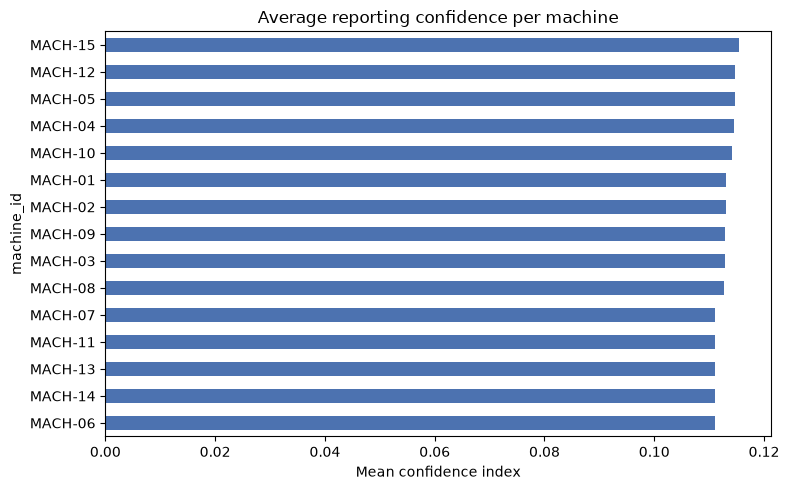

In [19]:
by_machine = (
    df.groupby(config.MACHINE_COLUMN)[config.CONFIDENCE_COLUMN]
    .mean()
    .sort_values()
)

ax = by_machine.plot.barh(figsize=(8, 5), color="#4C72B0")
ax.set_xlabel("Mean confidence index")
ax.set_title("Average reporting confidence per machine")
plt.tight_layout()
plt.show()

### 5.2 Severity by shift

Cross-tabulate severity against the work shift to spot risky time slots.

In [20]:
severity_num = pd.to_numeric(df[config.SEVERITY_COLUMN], errors="coerce")
crosstab = df.assign(severity=severity_num).pivot_table(
    index=config.SHIFT_COLUMN,
    values="severity",
    aggfunc=["count", "mean"],
)
crosstab

,count,mean
,severity,severity
shift,,
apres-midi,310,1.645161
matin,312,1.653846
nuit,278,1.708633


### 5.3 Number of incidents by severity and machine

Contingency table (each row is one incident), shown as a table and a
stacked bar chart.

severity,1,2,3,4,5
machine_id,,,,,
MACH-05,35,17,7,2,1
MACH-04,33,18,11,1,1
MACH-09,37,19,3,3,0
MACH-15,29,16,3,3,0
MACH-10,37,23,12,2,0
MACH-12,26,26,8,2,0
MACH-08,37,20,7,2,0
MACH-01,23,24,6,2,0
MACH-11,21,18,2,2,0


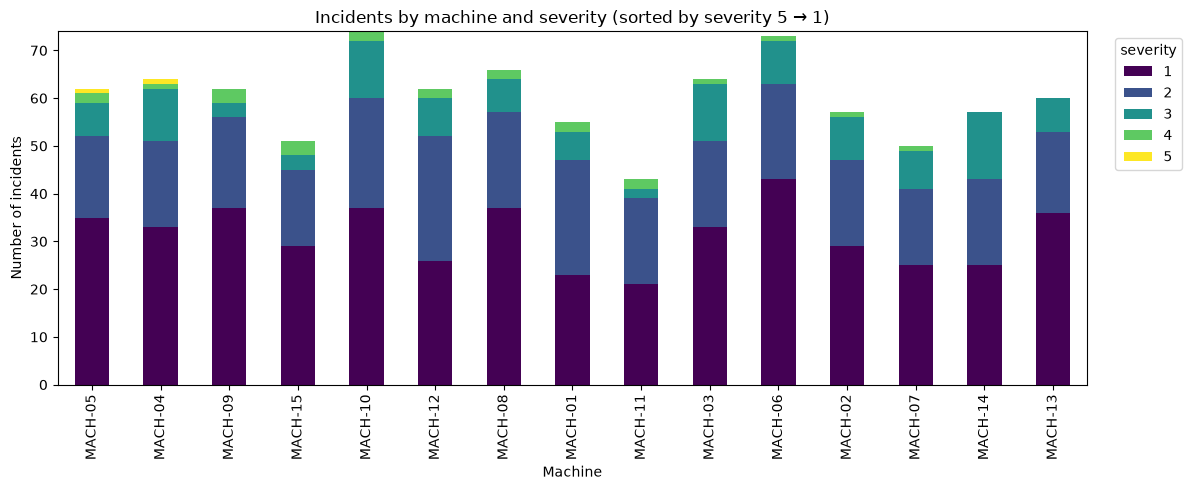

In [21]:
ct_machine = pd.crosstab(df[config.MACHINE_COLUMN], df[config.SEVERITY_COLUMN])
# Order rows by severity: most severity-5 first, then 4, 3, 2, 1.
severity_order = sorted(ct_machine.columns, reverse=True)
ct_machine = ct_machine.sort_values(by=severity_order, ascending=False)
display(ct_machine)

ax = ct_machine.plot.bar(stacked=True, figsize=(12, 5), colormap="viridis")
ax.set_xlabel("Machine")
ax.set_ylabel("Number of incidents")
ax.set_title("Incidents by machine and severity (sorted by severity 5 → 1)")
ax.legend(title="severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5.4 Number of incidents by severity and operator

`operator_name` is the **pseudonymised** operator id (HMAC), so this keeps
the analysis without re-identifying anyone. Many operators exist, so we show
the top 10 by total incident count.

severity,1,2,3,4,5
operator_name,,,,,
3edd0c1d48105a72,41,33,9,4,1
bd0bc817907ee4ef,41,41,11,3,1
7dbec0b1e9bc4bb2,50,20,20,3,0
a9a23ddd3ed5035f,63,24,11,3,0
0f91661e3337f8f5,51,30,17,2,0
7350eb0988b06c76,57,18,13,2,0
2c7f77aaeb432773,44,30,9,2,0
a89985989bad7e23,35,36,8,2,0
6be638e1d5e0f619,42,32,10,1,0


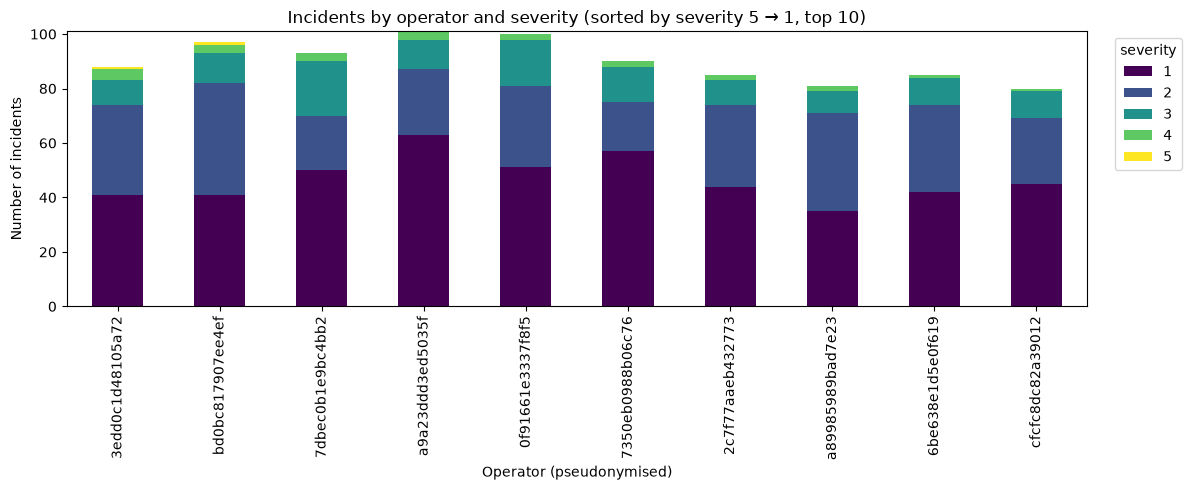

In [22]:
ct_operator = pd.crosstab(df["operator_name"], df[config.SEVERITY_COLUMN])
# Order rows by severity: most severity-5 first, then 4, 3, 2, 1.
severity_order = sorted(ct_operator.columns, reverse=True)
top_operators = ct_operator.sort_values(by=severity_order, ascending=False).head(10)
display(top_operators)

ax = top_operators.plot.bar(stacked=True, figsize=(12, 5), colormap="viridis")
ax.set_xlabel("Operator (pseudonymised)")
ax.set_ylabel("Number of incidents")
ax.set_title("Incidents by operator and severity (sorted by severity 5 → 1, top 10)")
ax.legend(title="severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5.5 Number of incidents by shift and severity

Count of incidents per shift broken down by severity (grouped bars).

severity,1,2,3,4,5
shift,,,,,
apres-midi,168,94,39,8,1
matin,163,99,45,5,0
nuit,138,95,34,10,1


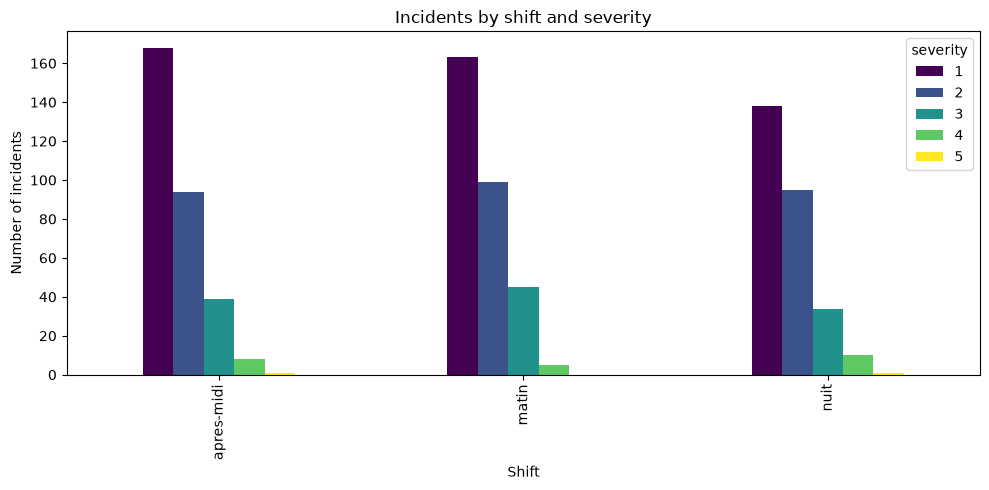

In [23]:
ct_shift = pd.crosstab(df[config.SHIFT_COLUMN], df[config.SEVERITY_COLUMN])
display(ct_shift)

ax = ct_shift.plot.bar(figsize=(10, 5), colormap="viridis")
ax.set_xlabel("Shift")
ax.set_ylabel("Number of incidents")
ax.set_title("Incidents by shift and severity")
ax.legend(title="severity")
plt.tight_layout()
plt.show()

### 5.6 Which operators use which machines

Heatmap of incident counts per operator (pseudonymised) and machine: a
filled cell means that operator reported incidents on that machine.

In [ ]:
ct_op_machine = pd.crosstab(df["operator_name"], df[config.MACHINE_COLUMN])
display(ct_op_machine)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(ct_op_machine.values, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(ct_op_machine.shape[1]))
ax.set_xticklabels(ct_op_machine.columns, rotation=90)
ax.set_yticks(range(ct_op_machine.shape[0]))
ax.set_yticklabels([op[:8] for op in ct_op_machine.index])  # short pseudonym
ax.set_xlabel("Machine")
ax.set_ylabel("Operator (pseudonymised)")
ax.set_title("Operator x machine usage (incident counts)")

# Annotate each cell with its count.
for i in range(ct_op_machine.shape[0]):
    for j in range(ct_op_machine.shape[1]):
        ax.text(j, i, ct_op_machine.values[i, j], ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Incident count")
plt.tight_layout()
plt.show()

### 5.7 Number of incidents per signal

Count of incidents where each `type_` signal is active. An incident can
trigger several signals, so the totals can sum to more than the number of
incidents.

In [ ]:
present_signals = [c for c in config.SIGNAL_COLUMNS if c in df.columns]
signal_counts = (
    df[present_signals].fillna(0).astype(int).sum().sort_values(ascending=False)
)
signal_counts.index = [s.replace("type_", "") for s in signal_counts.index]
display(signal_counts)

ax = signal_counts.plot.bar(figsize=(11, 5), color="#4C72B0")
ax.set_xlabel("Signal")
ax.set_ylabel("Number of incidents")
ax.set_title("Number of incidents per signal")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.8 Correlation matrix of incident signals

Correlation between the `type_` signal columns only (each signal is 0/1).
A high positive value means two signals tend to fire together on the same
incident.

> The standard `corr_incidents_signals.png` artifact also includes
> `severity`; this cell is restricted to the `type_` signals, as requested.

In [ ]:
present_signals = [c for c in config.SIGNAL_COLUMNS if c in df.columns]
corr = df[present_signals].apply(pd.to_numeric, errors="coerce").corr()
corr.index = [s.replace("type_", "") for s in corr.index]
corr.columns = [s.replace("type_", "") for s in corr.columns]
display(corr.round(2))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)

ax.set_title("Correlation matrix of incident signals (type_ columns)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5b. Standard production graphs (reused from `src/visualization`)

These cells call the **exact same functions** used at each run and display
the saved PNGs inline. They regenerate the files inside `run_dir`.

> To avoid overwriting a committed run's PNGs, point the functions to a
> scratch folder instead of `run_dir`.

### 5.9 Incident distributions — day / week / shift

Covers `dist_incidents_day.png`, `dist_incidents_week.png`,
`dist_incidents_shift.png`.

In [ ]:
from IPython.display import Image, display
from src.visualization import distributions

for png_path in distributions.plot_all(df, run_dir):
    display(Image(filename=str(png_path)))

### 5.10 Signal & machine composite

Covers `hist_signals_machine.png` (3 panels: frequency per signal,
machine x signal heatmap, and confidence-index distribution).

In [ ]:
from src.visualization import histograms

png_path = histograms.plot_signals_by_machine(df, run_dir)
display(Image(filename=str(png_path)))

## 6. Promoting an analysis to production

When a cell above proves useful and stable:

1. Move the logic into the right module under `src/` (e.g. a new function in
   `src/visualization/`).
2. Wire it into `src/ingestion/runner.py` so every run produces it.
3. Add a unit test if it carries business logic.

Keep this notebook for exploration only — it is versioned in Git but **not**
tracked by DVC (see `CLAUDE.md`).